# Lesson 4.2 — The Manipulability Ellipsoid
**Module 6 · Unit 4 · Lesson 14**

Map the unit joint-velocity circle through J: the tool velocities trace an ellipse whose long/short radii are the max/min singular values (easy/hard directions). Near a singularity it flattens toward a line.

In [1]:
import numpy as np
def dh(th,d,a,al):
    ct,st,ca,sa=np.cos(th),np.sin(th),np.cos(al),np.sin(al)
    return np.array([[ct,-st*ca,st*sa,a*ct],[st,ct*ca,-ct*sa,a*st],[0,sa,ca,d],[0,0,0,1]])
def forward_chain(P,T,q):
    M=np.eye(4); Ms=[M.copy()]
    for i,(th0,d0,a,al) in enumerate(P):
        th,d=(th0+q[i],d0) if T[i]=="R" else (th0,d0+q[i]); M=M@dh(th,d,a,al); Ms.append(M.copy())
    return Ms
def geometric_jacobian(P,T,q):
    Ms=forward_chain(P,T,q); on=Ms[-1][:3,3]; J=np.zeros((6,len(q)))
    for i in range(len(q)):
        z=Ms[i][:3,2]; o=Ms[i][:3,3]
        if T[i]=="R": J[:3,i]=np.cross(z,on-o); J[3:,i]=z
        else: J[:3,i]=z
    return J
def Jv_planar(P,T,q): return geometric_jacobian(P,T,q)[:2,:]  # x,y rows for planar arms


## Map the unit joint-rate circle to the tool-velocity ellipse

ellipse max radius 2.067 == sigma_max 2.067
ellipse min radius 0.347 == sigma_min 0.347


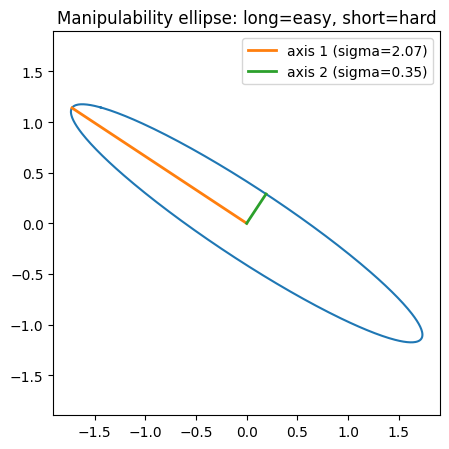

In [2]:
import matplotlib.pyplot as plt
checks=[]
P2=[(0,0,1,0),(0,0,1,0)]; T2=["R","R"]
Jv=Jv_planar(P2,T2,np.array([0.5,0.8]))
ang=np.linspace(0,2*np.pi,400); circ=np.vstack([np.cos(ang),np.sin(ang)])
ell=Jv@circ
U,S,Vt=np.linalg.svd(Jv)
rad=np.linalg.norm(ell,axis=0)
print("ellipse max radius",round(rad.max(),3),"== sigma_max",round(S[0],3))
print("ellipse min radius",round(rad.min(),3),"== sigma_min",round(S[1],3))
checks.append(np.isclose(rad.max(),S[0],atol=1e-2) and np.isclose(rad.min(),S[1],atol=1e-2))
plt.figure(figsize=(4.6,4.6)); plt.plot(ell[0],ell[1]); plt.axis('equal')
for i in range(2):
    plt.plot([0,U[0,i]*S[i]],[0,U[1,i]*S[i]],lw=2,label=f'axis {i+1} (sigma={S[i]:.2f})')
plt.legend(); plt.title('Manipulability ellipse: long=easy, short=hard'); plt.tight_layout(); plt.show()

## Near a singularity the ellipse flattens toward a line

In [3]:
Jstr=Jv_planar(P2,T2,np.array([0.4,0.02]))   # nearly straight
ell2=Jstr@circ; r2=np.linalg.norm(ell2,axis=0)
print("near-singular min radius:",round(r2.min(),4),"(approaching 0 -> impossible direction)")
checks.append(r2.min()<0.1)
assert all(checks), f"FAILED: {checks}"
print("All checks passed.")

near-singular min radius: 0.0112 (approaching 0 -> impossible direction)
All checks passed.
